In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import re
import funcoes
import plotly.graph_objects as go
pd.options.display.float_format = '{:.2f}'.format #para os números aparecerem com duas casas decimais
pd.set_option('display.max_columns', 50) #mostra 50 colunas ou o número desejado
pd.set_option('future.no_silent_downcasting', True)

dados = pd.read_excel("denuncias-2023-2025.xlsx")
dados.shape
seg = dados.copy()

In [2]:
funcoes.resumo(seg)

--- Formato ---
(336, 11)

--- Tipos de Dados ---
protocolo                              float64
data                            datetime64[ns]
nome_da_vítima                          object
tipo_de_violência_denunciada            object
bairro_da_vítima                        object
faixa_etária                            object
raça/cor                                object
sexo                                    object
vínculo_do_suspeito                     object
devolutiva                              object
ano                                    float64
dtype: object

--- Valores Nulos ---
protocolo                         1
data                              1
nome_da_vítima                    0
tipo_de_violência_denunciada      0
bairro_da_vítima                  1
faixa_etária                      0
raça/cor                          0
sexo                              0
vínculo_do_suspeito               1
devolutiva                      303
ano                               1


,protocolo,data,ano
count,335.00,335,335.00
mean,2801407.91,2024-07-03 11:32:03.582089472,2024.00
min,1681957.00,2023-03-14 00:00:00,2023.00
25%,2246554.00,2023-12-12 00:00:00,2023.00
50%,2784315.00,2024-07-15 00:00:00,2024.00
75%,3352891.00,2025-01-21 00:00:00,2025.00
max,4190066.00,2025-12-30 00:00:00,2025.00
std,665380.39,NaN,0.75


In [12]:
#fazendo os três dataframes de agrupamento faixa_etária, sexo para cada ano.  
anos = seg['ano'].unique() # Pega os anos únicos
dfs_anuais = {} # Dicionário para armazenar os novos dataframes

for ano in anos:
    # 1. Filtra o dataframe pelo ano atual da iteração
    df_ano = seg[seg['ano'] == ano]
    
    # 2. Agrupa o dataframe filtrado (ex: por Coluna1 e Coluna2, contando a ocorrência)
    df_agrupado = df_ano.groupby(['faixa_etária', 'sexo']).size().sort_values(ascending=True).reset_index(name='Contagem')
    
    # 3. Salva no dicionário ou cria uma variável específica
    dfs_anuais[f'df_{ano}'] = df_agrupado


df_2023 = dfs_anuais['df_2023.0']
df_2024 = dfs_anuais['df_2024.0']
df_2025 = dfs_anuais['df_2025.0']

In [27]:
#gerando uma tabela pivot para cada dataframe
# Dicionário para armazenar as novas tabelas pivot
pivots_gerados = {}

# 2. Iterando sobre o dicionário
for nome, df in dfs_anuais.items():
    # 3. Criando a tabela pivot para o DataFrame atual
    pivots_gerados[nome] = pd.pivot_table(
        df, 
        values='Contagem', 
        index='faixa_etária', 
        columns='sexo', 
        aggfunc='sum'
    ).sort_index(ascending=True)
pivots_gerados

{'df_2023.0': sexo           Feminino  Masculino  Não informado
 faixa_etária                                     
 60 a 64           12.00       4.00            NaN
 65 a 69            7.00       6.00            NaN
 70 a 74           10.00      11.00            NaN
 75 a 79            7.00       5.00            NaN
 80 a 84           12.00       4.00           1.00
 85 a 89            6.00       2.00            NaN
 90 a 94            1.00       2.00            NaN
 Não Informado      1.00        NaN           3.00,
 'df_2024.0': sexo           Feminino  Masculino  Não informado
 faixa_etária                                     
 60 a 64           21.00      15.00            NaN
 70 a 74           23.00       7.00            NaN
 75 a 79           23.00       3.00            NaN
 80 a 84           17.00       6.00            NaN
 85 a 89            7.00       3.00            NaN
 90 a 94            6.00       5.00            NaN
 Não Informado      5.00       1.00           4.00,
 'd

In [31]:
pivots_gerados.pop('df_nan')

sexo
faixa_etária


In [28]:
#alterar o valor da coluna masculino para negativo
for nome_df, df in pivots_gerados.items():
    #para conferir se todos os dataframes no dicionário tem a coluna 'Masculino' para realizar a alteração
    if 'Masculino' in df.columns: 
        df['Masculino'] = df['Masculino'] * -1

In [29]:
for objeto in pivots_gerados.items():
    print(objeto)

('df_2023.0', sexo           Feminino  Masculino  Não informado
faixa_etária                                     
60 a 64           12.00      -4.00            NaN
65 a 69            7.00      -6.00            NaN
70 a 74           10.00     -11.00            NaN
75 a 79            7.00      -5.00            NaN
80 a 84           12.00      -4.00           1.00
85 a 89            6.00      -2.00            NaN
90 a 94            1.00      -2.00            NaN
Não Informado      1.00        NaN           3.00)
('df_2024.0', sexo           Feminino  Masculino  Não informado
faixa_etária                                     
60 a 64           21.00     -15.00            NaN
70 a 74           23.00      -7.00            NaN
75 a 79           23.00      -3.00            NaN
80 a 84           17.00      -6.00            NaN
85 a 89            7.00      -3.00            NaN
90 a 94            6.00      -5.00            NaN
Não Informado      5.00      -1.00           4.00)
('df_2025.0', sexo  

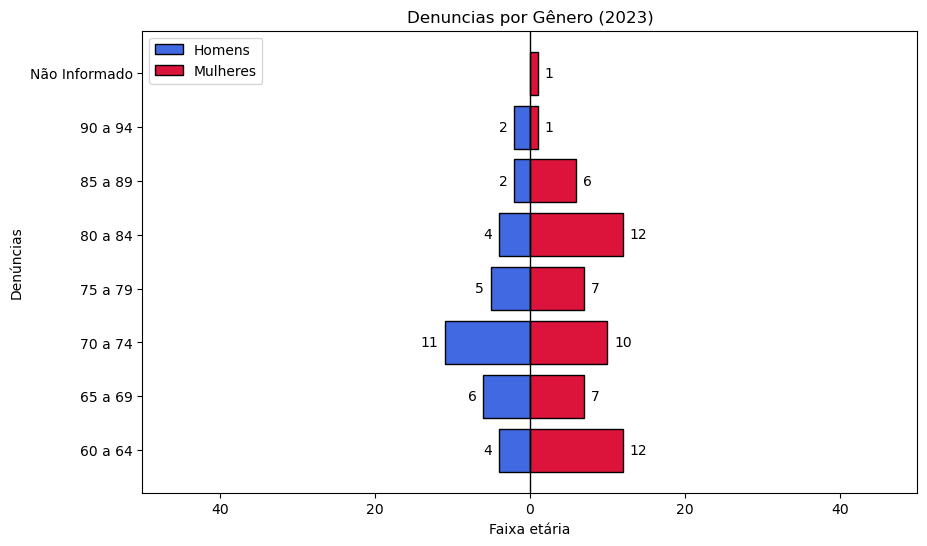

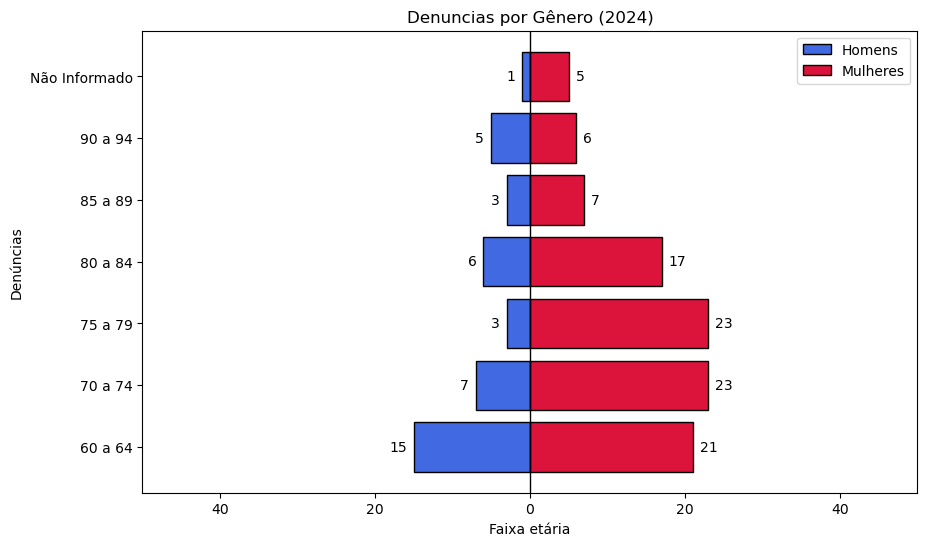

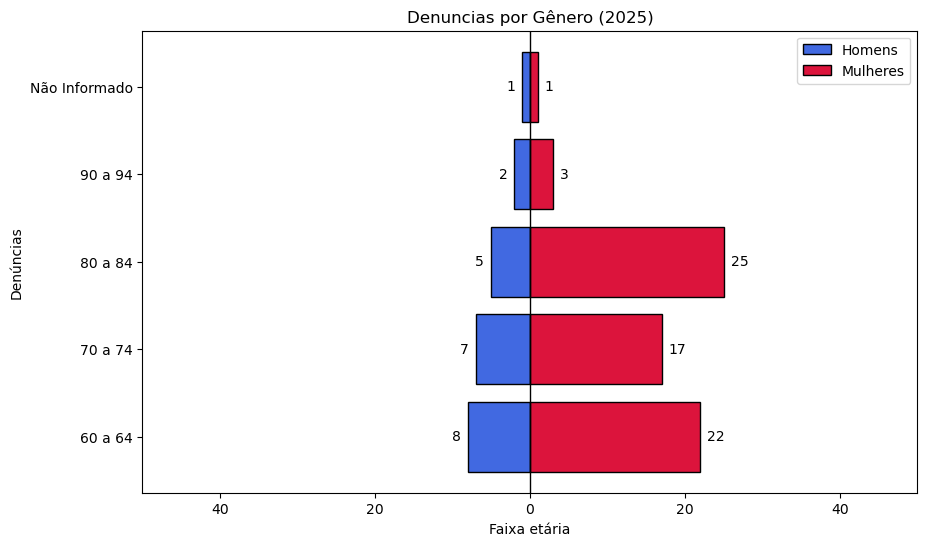

In [41]:
for nome_df, df in pivots_gerados.items():
    
    #formatando o ano do nome do gráfico, primeiro separa e pega o segundo item ([1] 2023.0) e depois o primeiro item ([2] 2023)
    ano_limpo = nome_df.split('_')[1].split('.')[0]
    
    # 2. Configuração do gráfico
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plotagem das barras
    ax.barh(df.index, df['Masculino'], color='royalblue', label='Homens', edgecolor = 'black')
    ax.barh(df.index, df['Feminino'], color='crimson', label='Mulheres', edgecolor = 'black')
    
    
    #Legendas, eixos e numerações das barras
    ax.set_title(f'Denuncias por Gênero ({ano_limpo})')
    ax.set_xlabel('Faixa etária')
    ax.set_ylabel('Denúncias')
    ax.legend()
    #formatando os rótulos e usando a função lambda para aplicar nas barras do lado negativo tbm
    
    
    #o primeiro laço é pra iterar sobre as barras
    #o segundo é pra definir os rótulos como strings se forem iguais a zero, e formatar como absoluto, para valor de cada barra
    for container in ax.containers:
        labels = ["" if v == 0 else f'{abs(v):.0f}' for v in container.datavalues]
        ax.bar_label(container, labels=labels, padding=5)
    
    #ajuste na escala do eixo x
    #limite_maximo = max(max(df['Feminino']), abs(min(df['Masculino']))) + 5
    #ax.set_xlim(-limite_maximo, limite_maximo)
    ax.set_xlim(-50, 50)
    
    #formatando os rótulos do eixo x
    ax.xaxis.set_major_formatter(lambda x, pos: f'{abs(int(x))}')
    
    
    # Linha central de separação
    ax.axvline(0, color='black', linewidth=1)
    
    plt.savefig(f'Denuncias-genero-({ano_limpo}).png', dpi=300, bbox_inches='tight')